# Notebook 8 — Decision Trees

A **Decision Tree** predicts something by asking a series of yes/no
questions, one after another, until it reaches an answer — a lot like
playing "20 Questions."

We'll use our retail dataset again, and actually look inside the tree to
see the questions it learned to ask.

### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

### Load the Data

Same retail data, with the `HighValue` label (1 = above median order
price, 0 = below).

In [3]:
data = pd.read_csv("data.csv", encoding="latin1")
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data = data.sample(200, random_state=1).reset_index(drop=True)
median_price = data["TotalPrice"].median()
data["HighValue"] = (data["TotalPrice"] > median_price).astype(int)
X = data[["Quantity", "UnitPrice"]]
y = data["HighValue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
data[["Quantity", "UnitPrice", "HighValue"]].head()

,Quantity,UnitPrice,HighValue
0,6,7.95,1
1,2,1.25,0
2,3,1.25,0
3,1,8.47,0
4,2,3.75,0


## 1. Decision Tree

A **Decision Tree** is a model shaped like an upside-down tree. It starts
with one question, and depending on the answer, branches off to another
question — and so on — until it reaches a final prediction.

## 2. Root Node

The **root node** is the very first question at the top of the tree — the
one that splits the *entire* dataset for the first time. It's chosen
because it does the best job of separating the classes right away.

## 3. Internal Node

An **internal node** is any question inside the tree that isn't the first
or the last — it takes the group of data that reached it and splits it
again into smaller groups.

## 4. Leaf Node

A **leaf node** is an endpoint of the tree — there's no more splitting
after it. It holds the final prediction (e.g. "High Value" or "Low
Value").

## 5. Splitting

**Splitting** is the process of dividing data into two groups based on a
question, like "Is UnitPrice > 15?". The tree tries many possible
questions and picks the one that separates the classes best.

## 6. Entropy

**Entropy** measures how mixed up or "impure" a group of data is.

- Entropy = 0 → the group is all one class (perfectly pure)
- Entropy = 1 → the group is a 50/50 mix (as mixed as possible)

The tree prefers splits that reduce entropy the most.

In [5]:
def entropy(labels):
    probs = labels.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))
print("Entropy of the whole dataset:", round(entropy(y), 3))

Entropy of the whole dataset: 1.0


## 7. Information Gain

**Information Gain** is how much entropy drops after a split. The bigger
the drop, the more useful that question was. The tree always picks the
split with the highest information gain at each step.

## 8. Gini Impurity

**Gini Impurity** is another way (besides entropy) to measure how mixed a
group is. It's a bit faster to compute and often gives similar results to
entropy in practice 

- Gini = 0 → perfectly pure group
- Higher Gini → more mixed group

In [7]:
def gini(labels):
    probs = labels.value_counts(normalize=True)
    return 1 - np.sum(probs ** 2)
print("Gini impurity of the whole dataset:", round(gini(y), 3))

Gini impurity of the whole dataset: 0.5


## 9. Training and Visualizing the Tree

Let's train a small tree (using entropy) and actually look inside it.

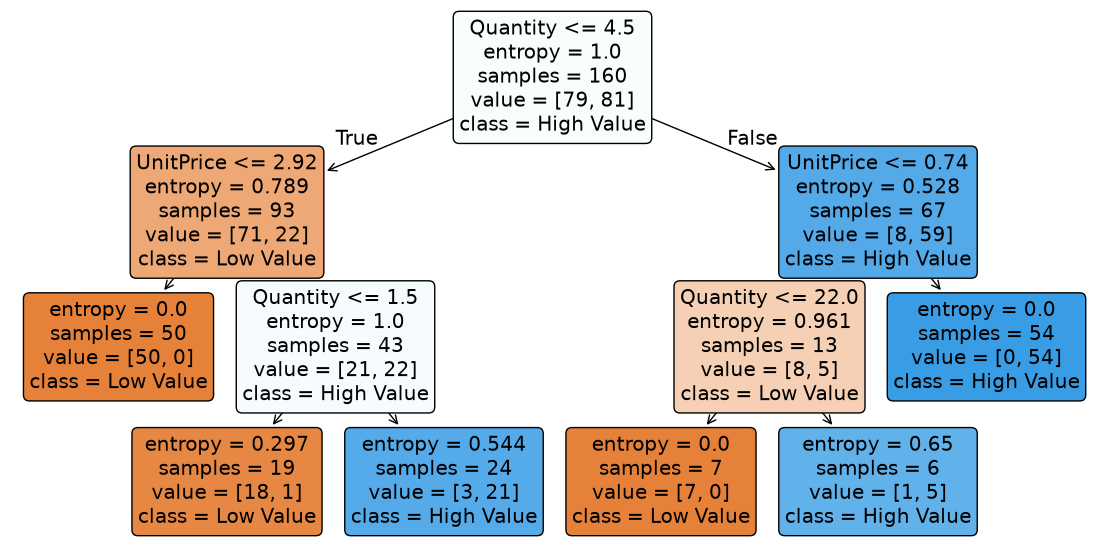

In [8]:
tree_model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=1)
tree_model.fit(X_train, y_train)
plt.figure(figsize=(14, 7))
plot_tree(tree_model, feature_names=["Quantity", "UnitPrice"],
          class_names=["Low Value", "High Value"], filled=True, rounded=True)
plt.show()

## 10. How the Tree Makes a Prediction

To predict a new order, the tree starts at the **root node** and answers
each question with that order's data, following the "True" or "False"
branch each time, until it lands on a **leaf node** — that leaf's majority
class is the prediction.

Let's trace this in plain text for one example.

In [10]:
example = X_test.iloc[[0]]
actual = y_test.iloc[0]
prediction = tree_model.predict(example)[0]
print("Example order:", example.to_dict("records")[0])
print("Actual label:", actual, "| Predicted label:", prediction)
print("\nRead the rules above top to bottom, following the branch that")
print("matches this order's Quantity and UnitPrice, until you hit a leaf.")

Example order: {'Quantity': 1, 'UnitPrice': 9.95}
Actual label: 1 | Predicted label: 0

Read the rules above top to bottom, following the branch that
matches this order's Quantity and UnitPrice, until you hit a leaf.


## 11. Tree Depth

**Tree depth** is how many levels of questions the tree has, from root to
leaf. A shallow tree asks few questions (simple, may miss patterns); a deep
tree asks many questions (detailed, but risks memorizing noise).

In [11]:
for depth in [1, 2, 3, 5, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=1)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"max_depth={depth}: train accuracy={train_acc:.2f}, test accuracy={test_acc:.2f}")

max_depth=1: train accuracy=0.81, test accuracy=0.70
max_depth=2: train accuracy=0.91, test accuracy=0.72
max_depth=3: train accuracy=0.94, test accuracy=0.82
max_depth=5: train accuracy=0.99, test accuracy=0.88
max_depth=10: train accuracy=1.00, test accuracy=0.90
max_depth=None: train accuracy=1.00, test accuracy=0.90


## 12. Overfitting

**Overfitting** happens when the tree grows so deep that it starts
memorizing the training data's noise, instead of learning the real
pattern. You can spot it above: as `max_depth` grows, training accuracy
keeps climbing, but test accuracy stops improving (or gets worse).

## 13. Pruning

**Pruning** means trimming back an overgrown tree to make it simpler —
either by limiting its depth upfront, or cutting off branches afterward
that don't really help. This reduces overfitting and often improves
performance on new data.